
================ Experiment Ranking ================



,Experiment,Accuracy,Accuracy_std,F1 Macro,F1 Micro,AUC,AP
0,EXPERIMENT_2d_leg_typ1_smallcnn_randomseed,98.580977,0.134071,0.985318,0.985810,0.999240,0.998868
1,EXPERIMENT_resnet_1d_selfeeg_typ1_randomseed,98.395887,0.277825,0.983300,0.983959,0.998914,0.998530
2,EXPERIMENT_2d_cheb_typ1_smallcnn_randomseed,98.344473,0.128020,0.982857,0.983445,0.999093,0.998637
3,EXPERIMENT_2d_resnet_typ1_ECGresnet_pretrain_F...,98.231362,0.201107,0.981901,0.982314,0.998787,0.998327
4,EXPERIMENT_2d_resnet_typ1_ECGresnet_randomseed,98.087404,0.388847,0.980496,0.980874,0.998641,0.998025
5,EXPERIMENT_resnet_1d_selfeeg_typ1_singlelead1_...,98.025707,0.242791,0.979872,0.980257,0.998147,0.997212
6,EXPERIMENT_resnet_1d_selfeeg_typ2_randomseed,97.782725,0.202570,0.977827,0.977827,0.998334,0.996851
7,EXPERIMENT_2d_cheb_typ2_smallcnn_randomseed,97.533393,0.124348,0.975291,0.975334,0.997497,0.994458
8,EXPERIMENT_2d_resnet_ECGresnet_randomseed,97.497774,0.164797,0.974930,0.974978,0.997519,0.995561
9,EXPERIMENT_2d_resnet_typ2_ECGresnet_pretrain_F...,97.390917,0.262651,0.973893,0.973909,0.997039,0.994614


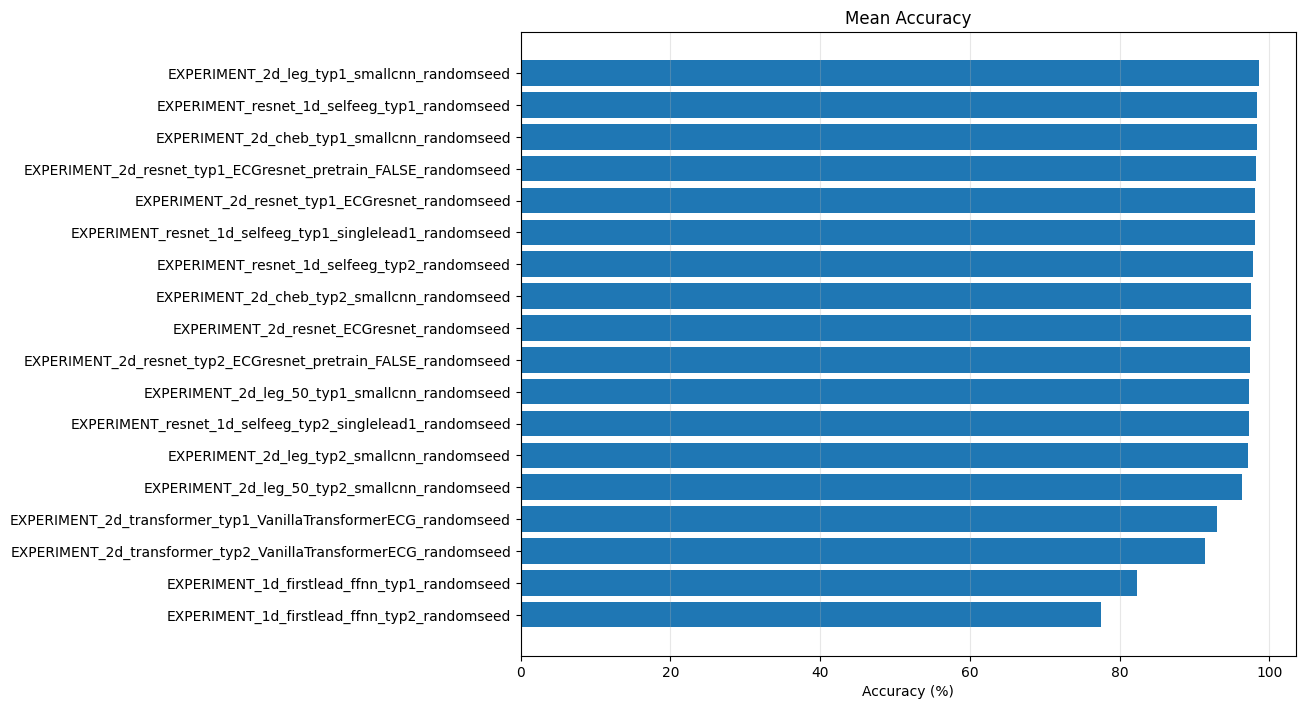

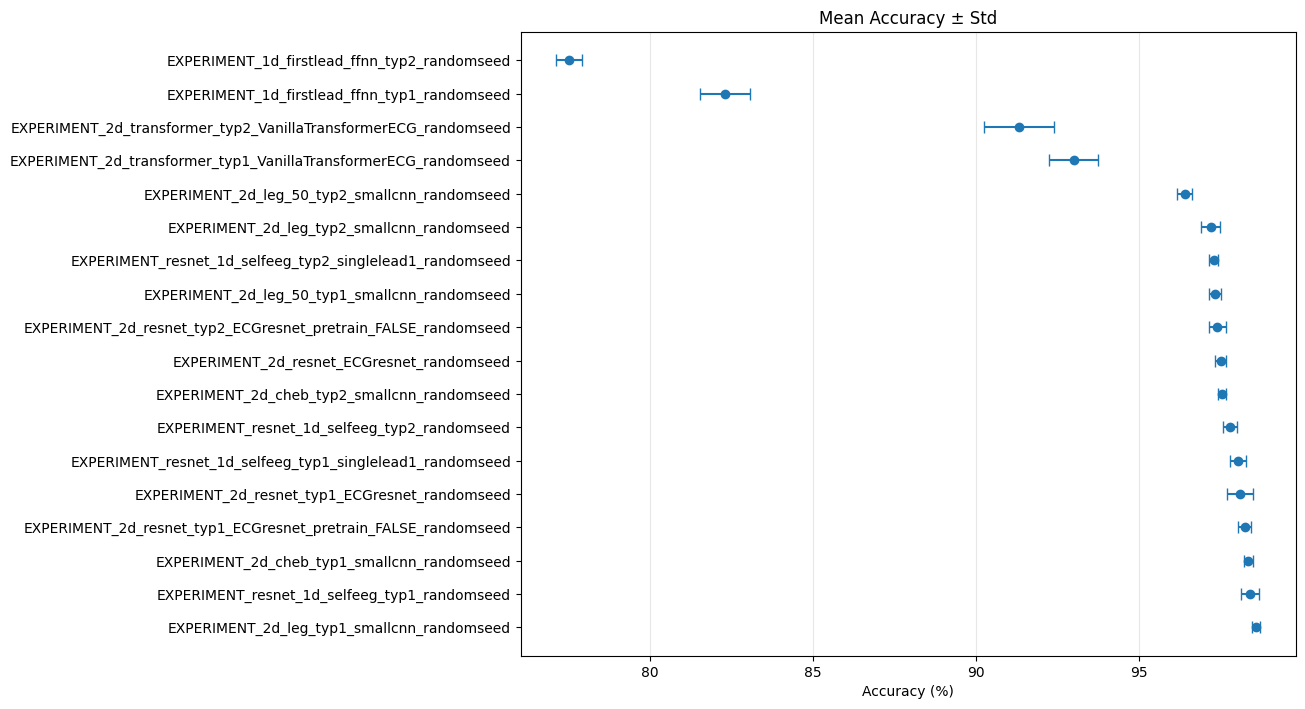

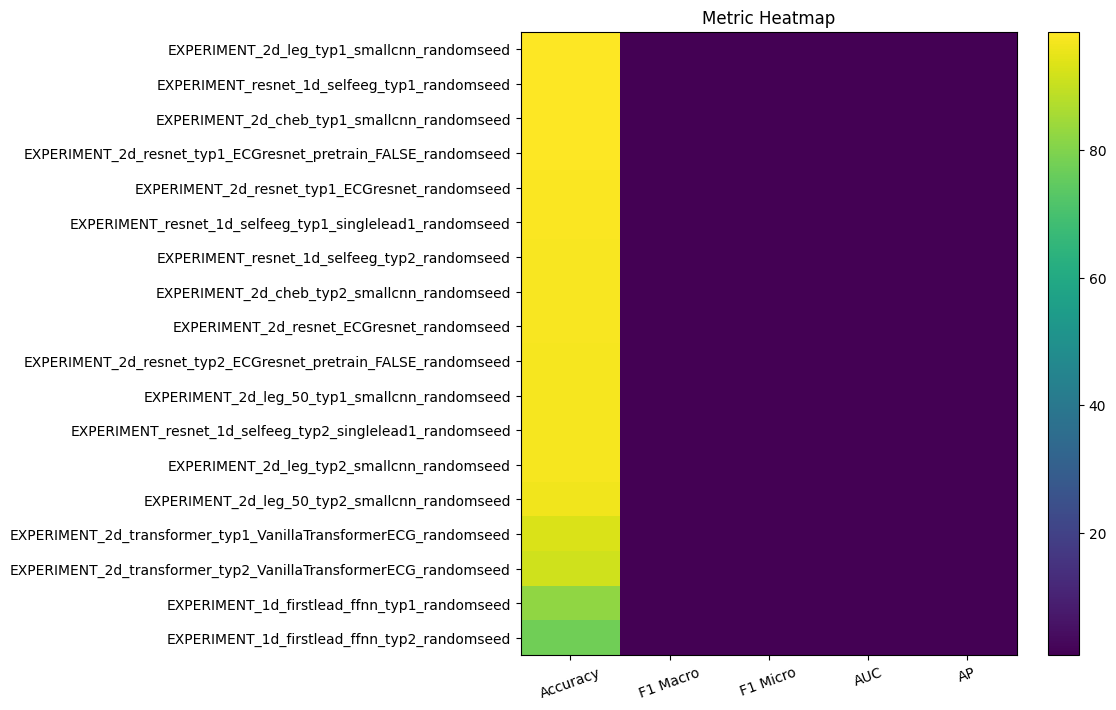

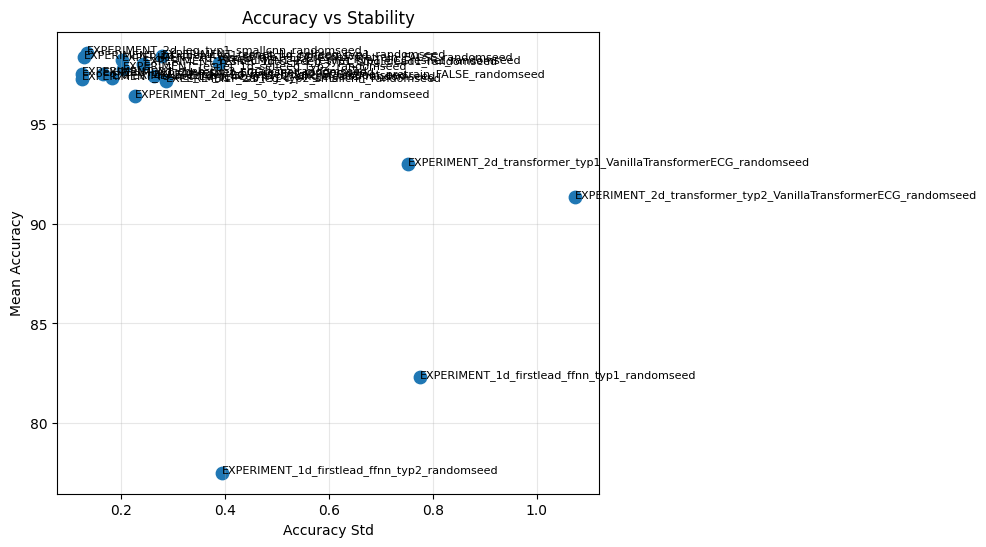

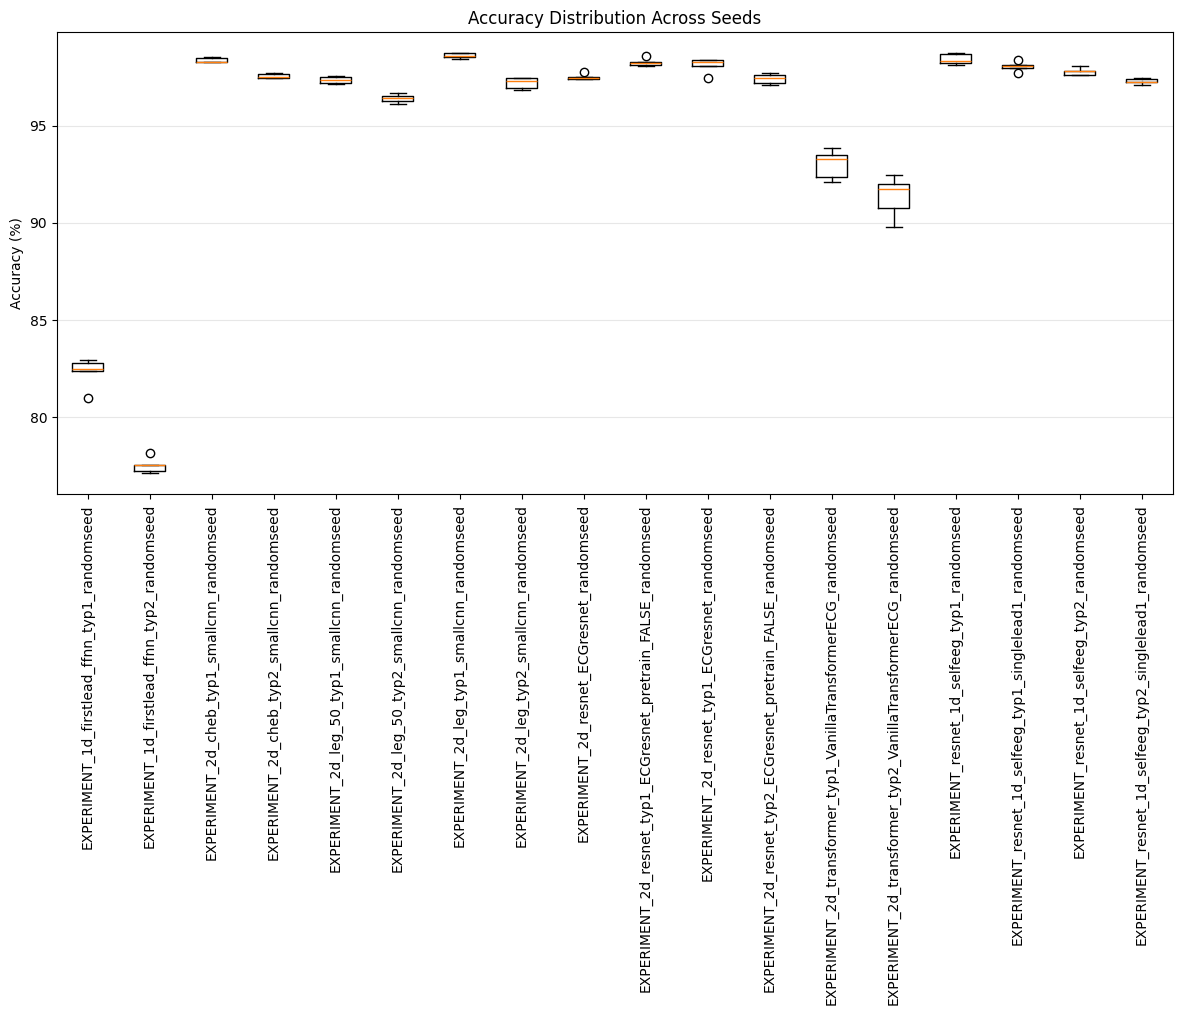

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Read all experiment summaries
# ----------------------------------------------------

MAIN_DIR = Path.cwd()

experiment_dirs = sorted(MAIN_DIR.glob("EXPERIMENT*_randomseed"))

rows = []
seed_data = {}

for exp in experiment_dirs:

    csvs = list(exp.glob("*.csv"))

    if len(csvs) == 0:
        print(f"Skipping {exp.name} (no csv)")
        continue

    df = pd.read_csv(csvs[0])

    mean = df[df["seed"].astype(str) == "mean"]
    std = df[df["seed"].astype(str) == "std"]

    if len(mean) == 0:
        continue

    mean = mean.iloc[0]
    std = std.iloc[0]

    rows.append({
        "Experiment": exp.name,
        "Accuracy": mean["accuracy"],
        "Accuracy_std": std["accuracy"],
        "F1 Macro": mean["f1_macro"],
        "F1 Micro": mean["f1_micro"],
        "AUC": mean["auc_macro"],
        "AP": mean["ap_micro"],
    })

    seed_df = df[pd.to_numeric(df["seed"], errors="coerce").notna()]
    seed_data[exp.name] = seed_df["accuracy"].astype(float).values

comparison = pd.DataFrame(rows)
comparison = comparison.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\n================ Experiment Ranking ================\n")
display(comparison)

# ----------------------------------------------------
# Plot 1 : Accuracy comparison
# ----------------------------------------------------

plt.figure(figsize=(10, max(5, len(comparison)*0.45)))

plt.barh(
    comparison["Experiment"],
    comparison["Accuracy"]
)

plt.gca().invert_yaxis()
plt.xlabel("Accuracy (%)")
plt.title("Mean Accuracy")
plt.grid(axis="x", alpha=0.3)

plt.show()

# ----------------------------------------------------
# Plot 2 : Accuracy ± Std
# ----------------------------------------------------

plt.figure(figsize=(10, max(5, len(comparison)*0.45)))

plt.errorbar(
    comparison["Accuracy"],
    comparison["Experiment"],
    xerr=comparison["Accuracy_std"],
    fmt='o',
    capsize=4
)

plt.xlabel("Accuracy (%)")
plt.title("Mean Accuracy ± Std")
plt.grid(axis="x", alpha=0.3)

plt.show()

# ----------------------------------------------------
# Plot 3 : Heatmap
# ----------------------------------------------------

metrics = comparison[
    ["Accuracy", "F1 Macro", "F1 Micro", "AUC", "AP"]
].values

fig, ax = plt.subplots(figsize=(8, max(5, len(comparison)*0.45)))

im = ax.imshow(metrics, aspect="auto")

ax.set_xticks(range(5))
ax.set_xticklabels(
    ["Accuracy", "F1 Macro", "F1 Micro", "AUC", "AP"],
    rotation=20
)

ax.set_yticks(range(len(comparison)))
ax.set_yticklabels(comparison["Experiment"])

ax.set_title("Metric Heatmap")

plt.colorbar(im)

plt.show()

# ----------------------------------------------------
# Plot 4 : Accuracy vs Std
# ----------------------------------------------------

plt.figure(figsize=(7,6))

plt.scatter(
    comparison["Accuracy_std"],
    comparison["Accuracy"],
    s=80
)

for _, row in comparison.iterrows():
    plt.text(
        row["Accuracy_std"],
        row["Accuracy"],
        row["Experiment"],
        fontsize=8
    )

plt.xlabel("Accuracy Std")
plt.ylabel("Mean Accuracy")
plt.title("Accuracy vs Stability")
plt.grid(alpha=0.3)

plt.show()

# ----------------------------------------------------
# Plot 5 : Boxplot of seed accuracies
# ----------------------------------------------------

labels = list(seed_data.keys())
values = [seed_data[k] for k in labels]

plt.figure(figsize=(max(10, len(labels)*0.8),6))

plt.boxplot(
    values,
    tick_labels=labels,
    vert=True
)

plt.xticks(rotation=90)

plt.ylabel("Accuracy (%)")
plt.title("Accuracy Distribution Across Seeds")

plt.grid(axis="y", alpha=0.3)

plt.show()


===== Ranking =====

                Experiment      Family  Accuracy  Accuracy_std  F1 Macro  F1 Micro      AUC       AP
      SmallCNN 2D Leg Typ1    SmallCNN 98.580977      0.134071  0.985318  0.985810 0.999240 0.998868
           SelfEEG 1D Typ1     SelfEEG 98.395887      0.277825  0.983300  0.983959 0.998914 0.998530
     SmallCNN 2D Cheb Typ1    SmallCNN 98.344473      0.128020  0.982857  0.983445 0.999093 0.998637
      ECGResNet 2D PT Typ1   ECGResNet 98.231362      0.201107  0.981901  0.982314 0.998787 0.998327
         ECGResNet 2D Typ1   ECGResNet 98.087404      0.388847  0.980496  0.980874 0.998641 0.998025
SelfEEG 1D SingleLead Typ1     SelfEEG 98.025707      0.242791  0.979872  0.980257 0.998147 0.997212
           SelfEEG 1D Typ2     SelfEEG 97.782725      0.202570  0.977827  0.977827 0.998334 0.996851
     SmallCNN 2D Cheb Typ2    SmallCNN 97.533393      0.124348  0.975291  0.975334 0.997497 0.994458
              ECGResNet 2D   ECGResNet 97.497774      0.164797  0.974

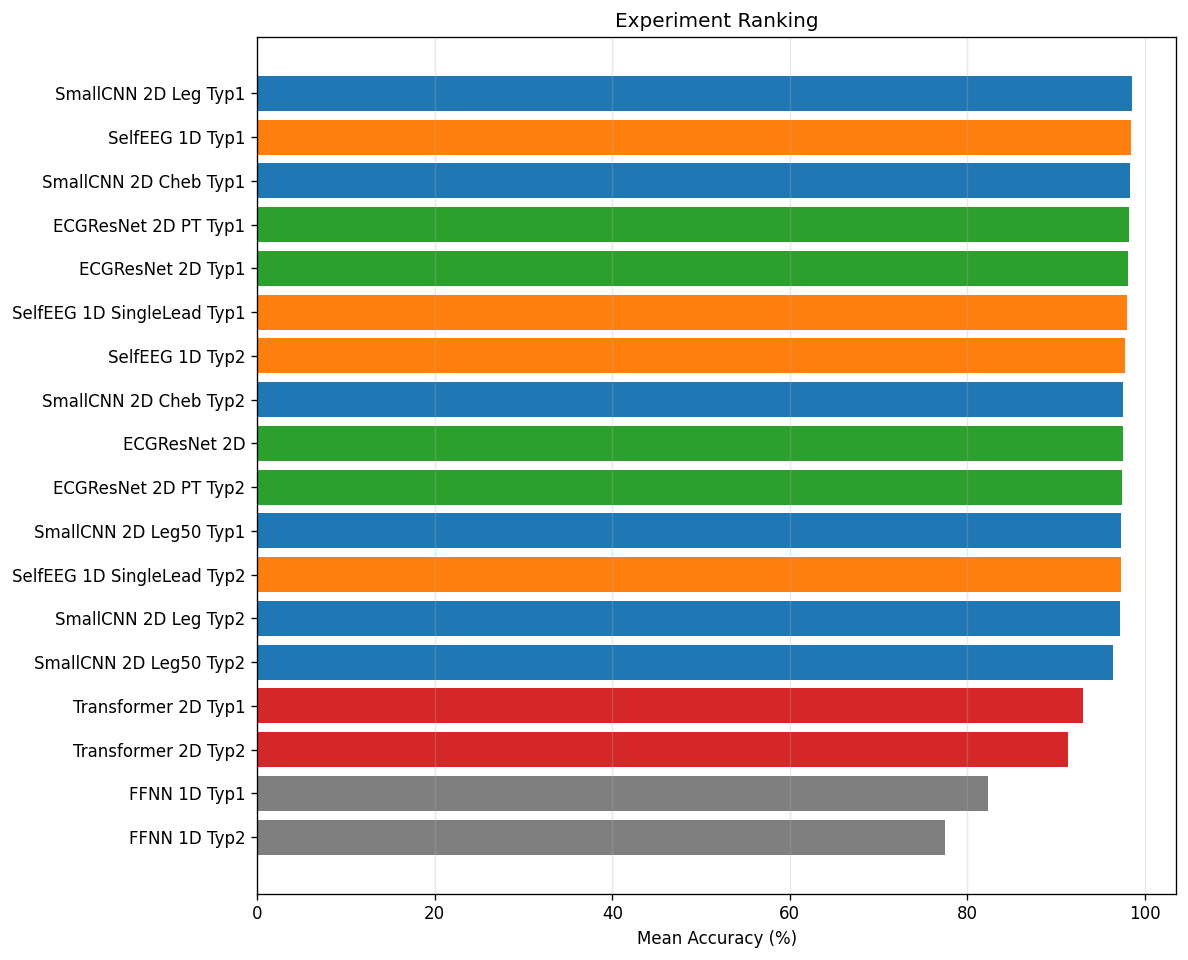

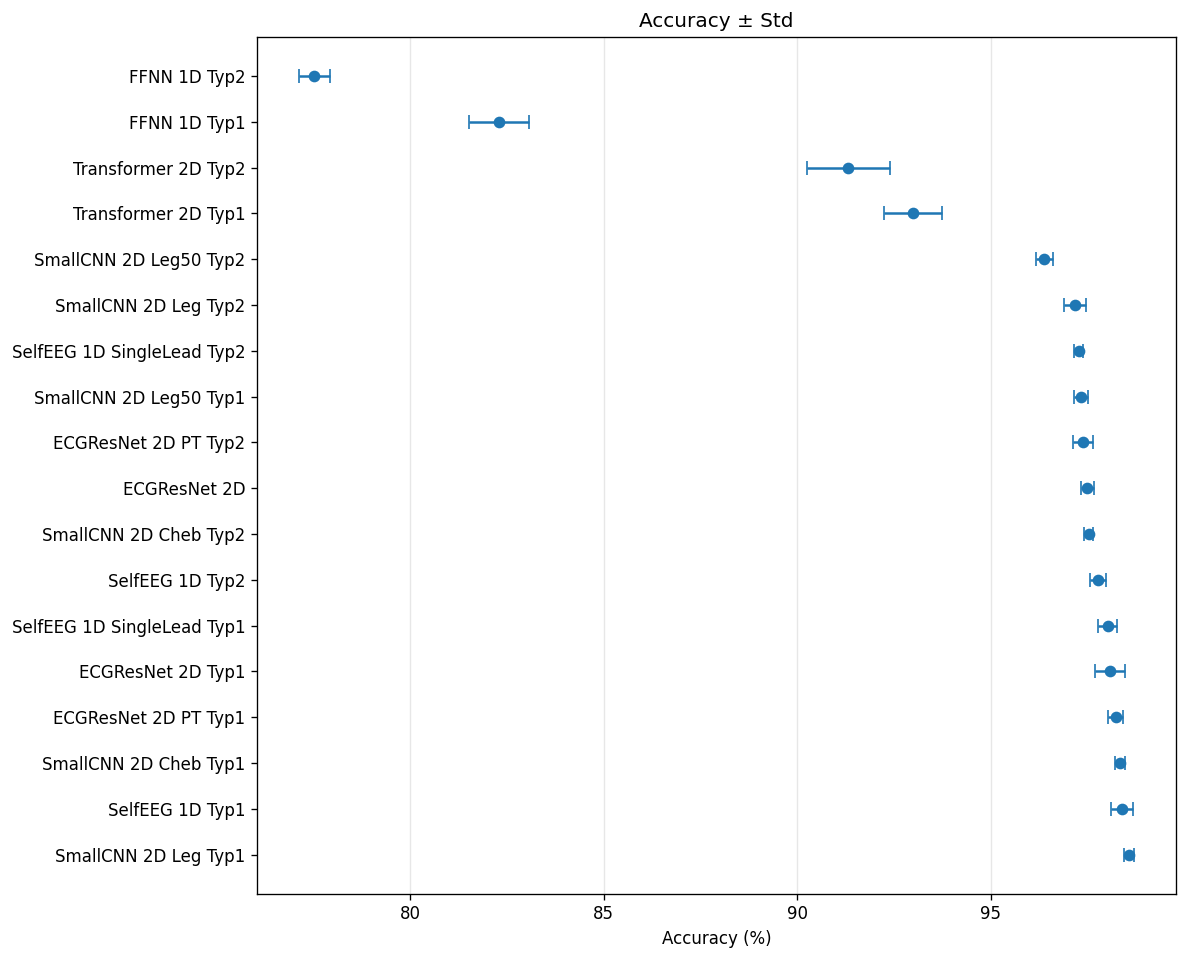

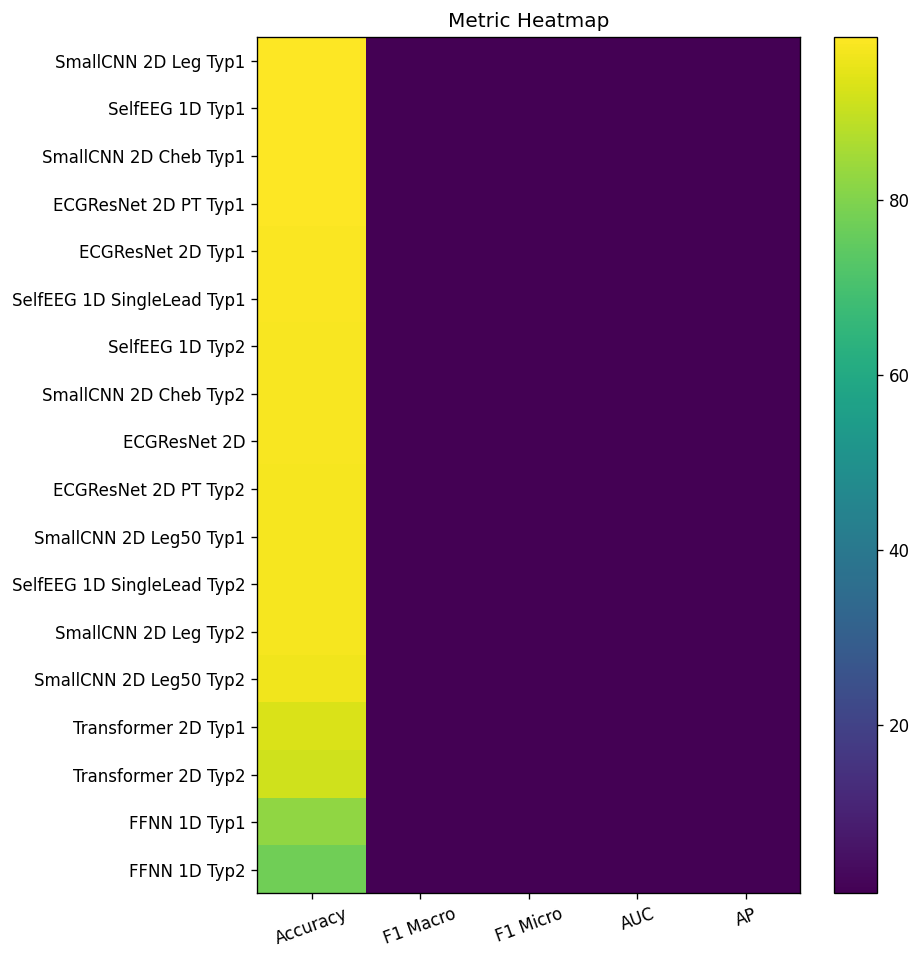

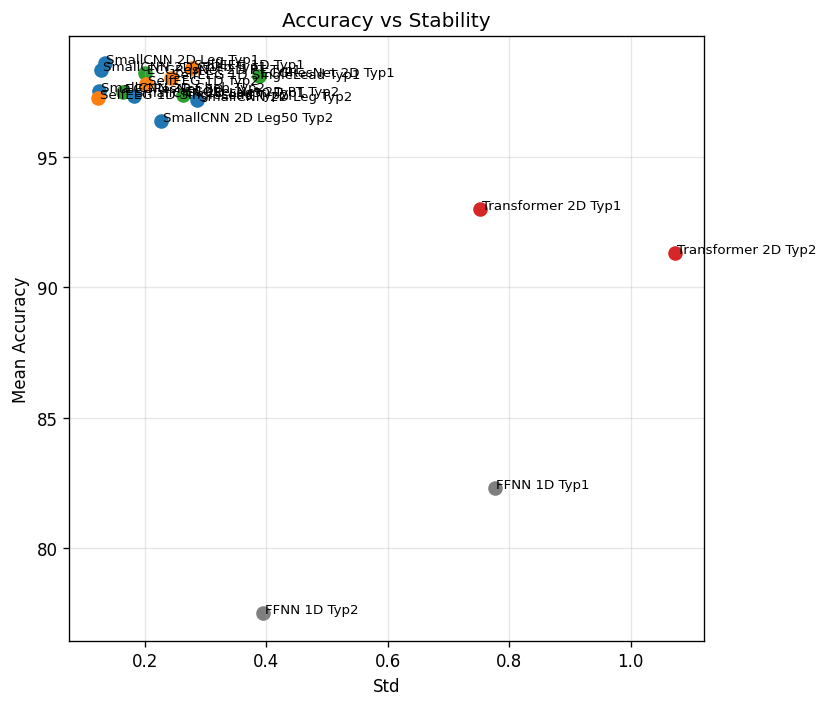

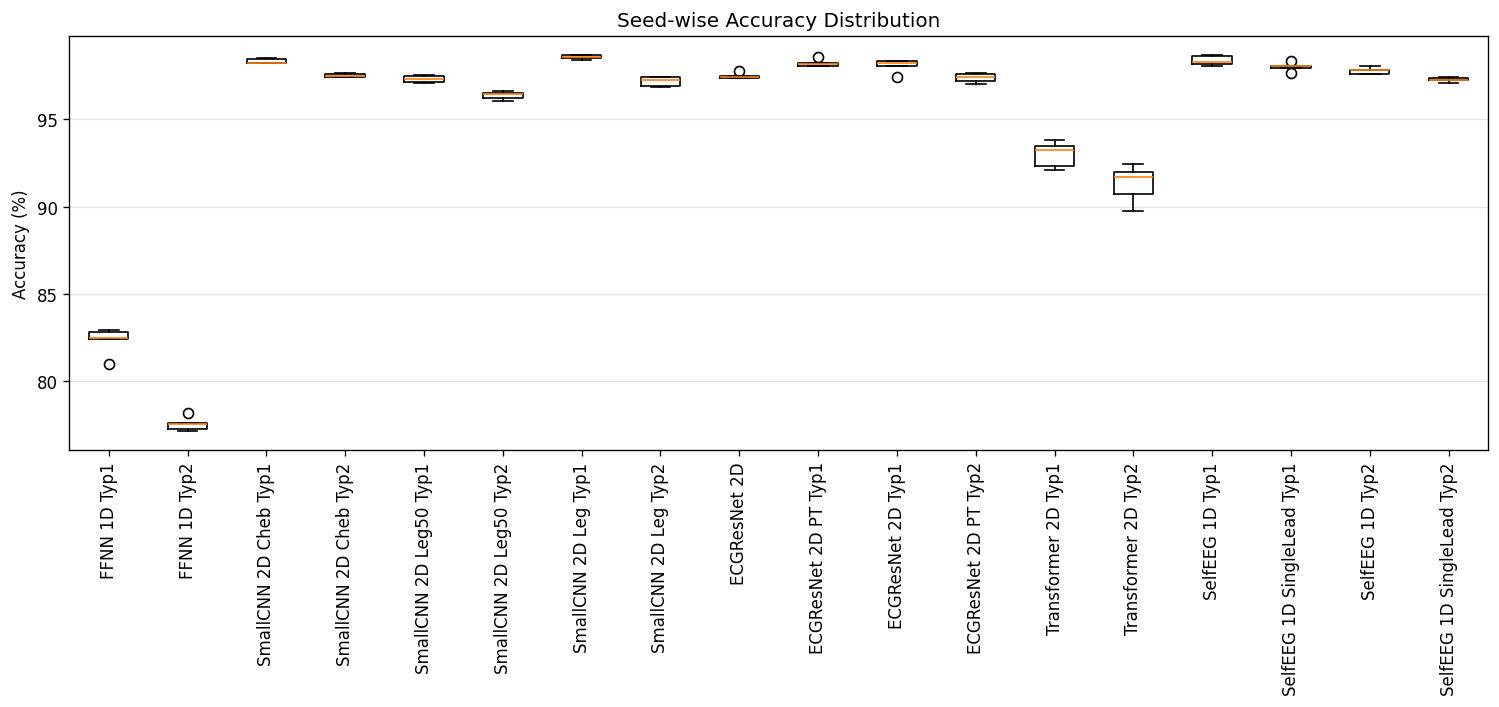

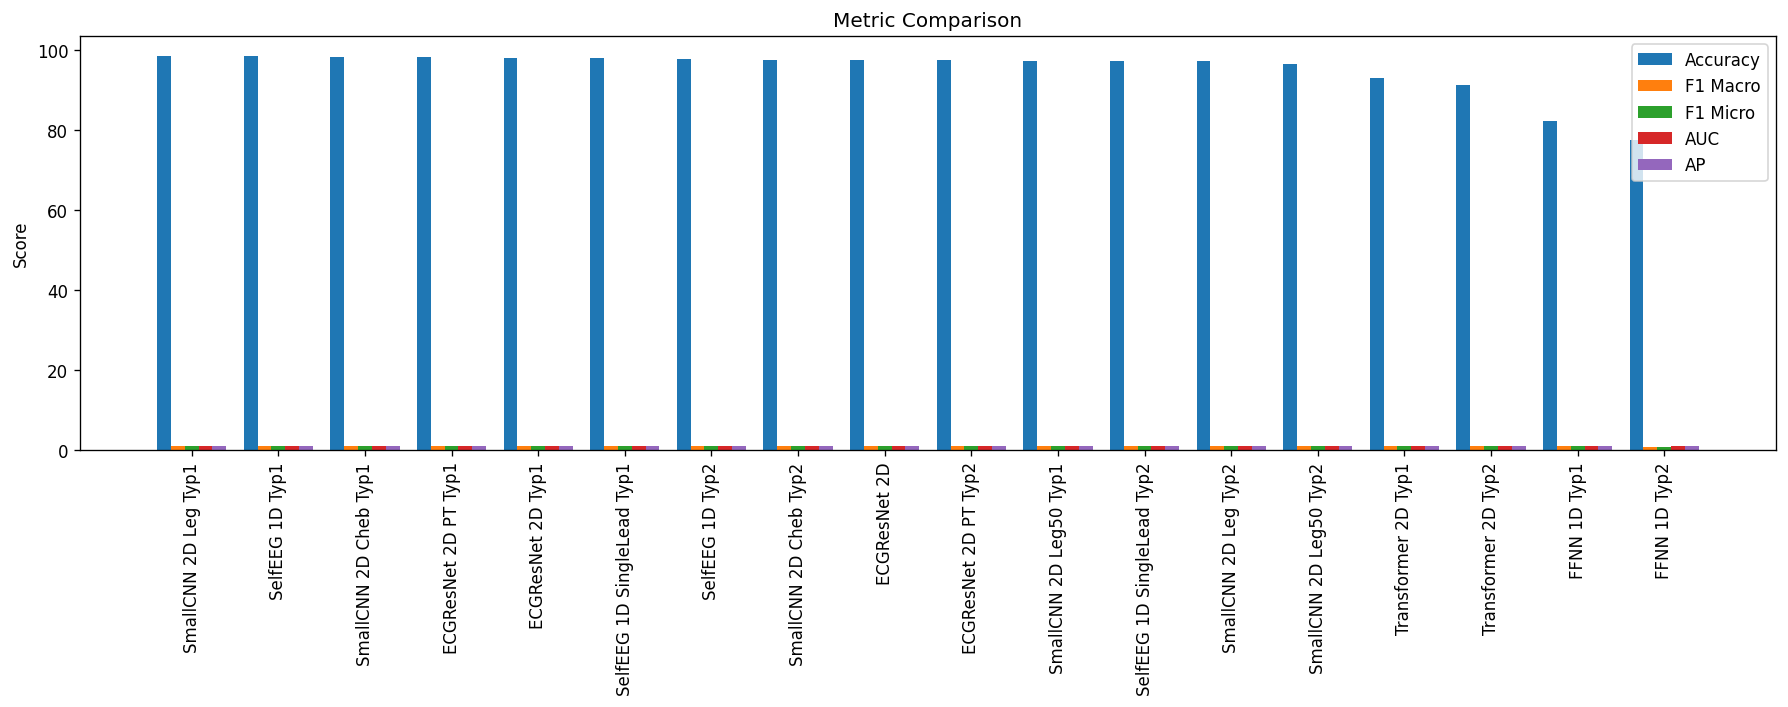

In [2]:

from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

MAIN_DIR = Path.cwd()

def pretty_name(folder):
    n = folder.replace("EXPERIMENT_","").replace("_randomseed","")
    label = []

    if "ffnn" in n.lower():
        label.append("FFNN")
    elif "transformer" in n.lower():
        label.append("Transformer")
    elif "selfeeg" in n.lower():
        label.append("SelfEEG")
    elif "ecgresnet" in n.lower():
        label.append("ECGResNet")
    elif "smallcnn" in n.lower():
        label.append("SmallCNN")
    else:
        label.append("Model")

    if "1d" in n:
        label.append("1D")
    elif "2d" in n:
        label.append("2D")

    if "leg_50" in n:
        label.append("Leg50")
    elif "leg" in n:
        label.append("Leg")
    elif "cheb" in n:
        label.append("Cheb")

    if "singlelead1" in n:
        label.append("SingleLead")

    if "pretrain" in n.lower():
        label.append("PT")

    m = re.search(r"typ([12])", n)
    if m:
        label.append(f"Typ{m.group(1)}")

    return " ".join(label)

def family(label):
    if label.startswith("SmallCNN"): return "SmallCNN"
    if label.startswith("ECGResNet"): return "ECGResNet"
    if label.startswith("SelfEEG"): return "SelfEEG"
    if label.startswith("Transformer"): return "Transformer"
    if label.startswith("FFNN"): return "FFNN"
    return "Other"

colors = {
    "SmallCNN":"tab:blue",
    "ECGResNet":"tab:green",
    "SelfEEG":"tab:orange",
    "Transformer":"tab:red",
    "FFNN":"tab:gray",
    "Other":"tab:purple"
}

rows=[]
seed_acc={}

for exp in sorted(MAIN_DIR.glob("EXPERIMENT*_randomseed")):
    csvs=list(exp.glob("*.csv"))
    if not csvs:
        continue
    df=pd.read_csv(csvs[0])

    mean=df[df.seed.astype(str)=="mean"]
    std=df[df.seed.astype(str)=="std"]
    if mean.empty or std.empty:
        continue
    mean=mean.iloc[0]
    std=std.iloc[0]

    name=pretty_name(exp.name)

    rows.append({
        "Experiment":name,
        "Family":family(name),
        "Accuracy":float(mean["accuracy"]),
        "Accuracy_std":float(std["accuracy"]),
        "F1 Macro":float(mean["f1_macro"]),
        "F1 Micro":float(mean["f1_micro"]),
        "AUC":float(mean["auc_macro"]),
        "AP":float(mean["ap_micro"])
    })

    seeds=df[pd.to_numeric(df.seed,errors="coerce").notna()]
    seed_acc[name]=seeds["accuracy"].astype(float).values

comp=pd.DataFrame(rows).sort_values("Accuracy",ascending=False).reset_index(drop=True)

print("\n===== Ranking =====\n")
print(comp.to_string(index=False))

# Bar
plt.figure(figsize=(10,max(5,len(comp)*0.45)))
plt.barh(comp["Experiment"],comp["Accuracy"],
         color=[colors[x] for x in comp["Family"]])
plt.gca().invert_yaxis()
plt.xlabel("Mean Accuracy (%)")
plt.title("Experiment Ranking")
plt.grid(axis="x",alpha=.3)
plt.tight_layout()
plt.show()

# Error bars
plt.figure(figsize=(10,max(5,len(comp)*0.45)))
plt.errorbar(comp["Accuracy"],comp["Experiment"],
             xerr=comp["Accuracy_std"],fmt="o",capsize=4)
plt.xlabel("Accuracy (%)")
plt.title("Accuracy ± Std")
plt.grid(axis="x",alpha=.3)
plt.tight_layout()
plt.show()

# Heatmap
metrics=["Accuracy","F1 Macro","F1 Micro","AUC","AP"]
fig,ax=plt.subplots(figsize=(8,max(5,len(comp)*0.45)))
im=ax.imshow(comp[metrics].values,aspect="auto")
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics,rotation=20)
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp["Experiment"])
ax.set_title("Metric Heatmap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# Scatter
plt.figure(figsize=(7,6))
for _,r in comp.iterrows():
    plt.scatter(r["Accuracy_std"],r["Accuracy"],
                color=colors[r["Family"]],s=60)
    plt.text(r["Accuracy_std"]+0.003,r["Accuracy"],r["Experiment"],fontsize=8)
plt.xlabel("Std")
plt.ylabel("Mean Accuracy")
plt.title("Accuracy vs Stability")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(max(10,len(seed_acc)*0.7),6))
labels=list(seed_acc.keys())
vals=[seed_acc[k] for k in labels]
plt.boxplot(vals,tick_labels=labels)
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Seed-wise Accuracy Distribution")
plt.grid(axis="y",alpha=.3)
plt.tight_layout()
plt.show()

# Grouped metrics
x=np.arange(len(comp))
width=0.16
fig,ax=plt.subplots(figsize=(15,6))
for i,m in enumerate(metrics):
    ax.bar(x+(i-2)*width,comp[m],width,label=m)
ax.set_xticks(x)
ax.set_xticklabels(comp["Experiment"],rotation=90)
ax.set_ylabel("Score")
ax.set_title("Metric Comparison")
ax.legend()
plt.tight_layout()
plt.show()


,Experiment,Accuracy,Std,F1 Macro,F1 Micro,AUC,AP
0,SmallCNN Leg Typ1,98.580977,0.134071,0.985318,0.985810,0.999240,0.998868
1,SelfEEG Typ1,98.395887,0.277825,0.983300,0.983959,0.998914,0.998530
2,SmallCNN Cheb Typ1,98.344473,0.128020,0.982857,0.983445,0.999093,0.998637
3,ECGresNet PT_off Typ1,98.231362,0.201107,0.981901,0.982314,0.998787,0.998327
4,ECGresNet Typ1,98.087404,0.388847,0.980496,0.980874,0.998641,0.998025
5,SelfEEG SingleLead Typ1,98.025707,0.242791,0.979872,0.980257,0.998147,0.997212
6,SelfEEG Typ2,97.782725,0.202570,0.977827,0.977827,0.998334,0.996851
7,SmallCNN Cheb Typ2,97.533393,0.124348,0.975291,0.975334,0.997497,0.994458
8,ECGresNet,97.497774,0.164797,0.974930,0.974978,0.997519,0.995561
9,ECGresNet PT_off Typ2,97.390917,0.262651,0.973893,0.973909,0.997039,0.994614


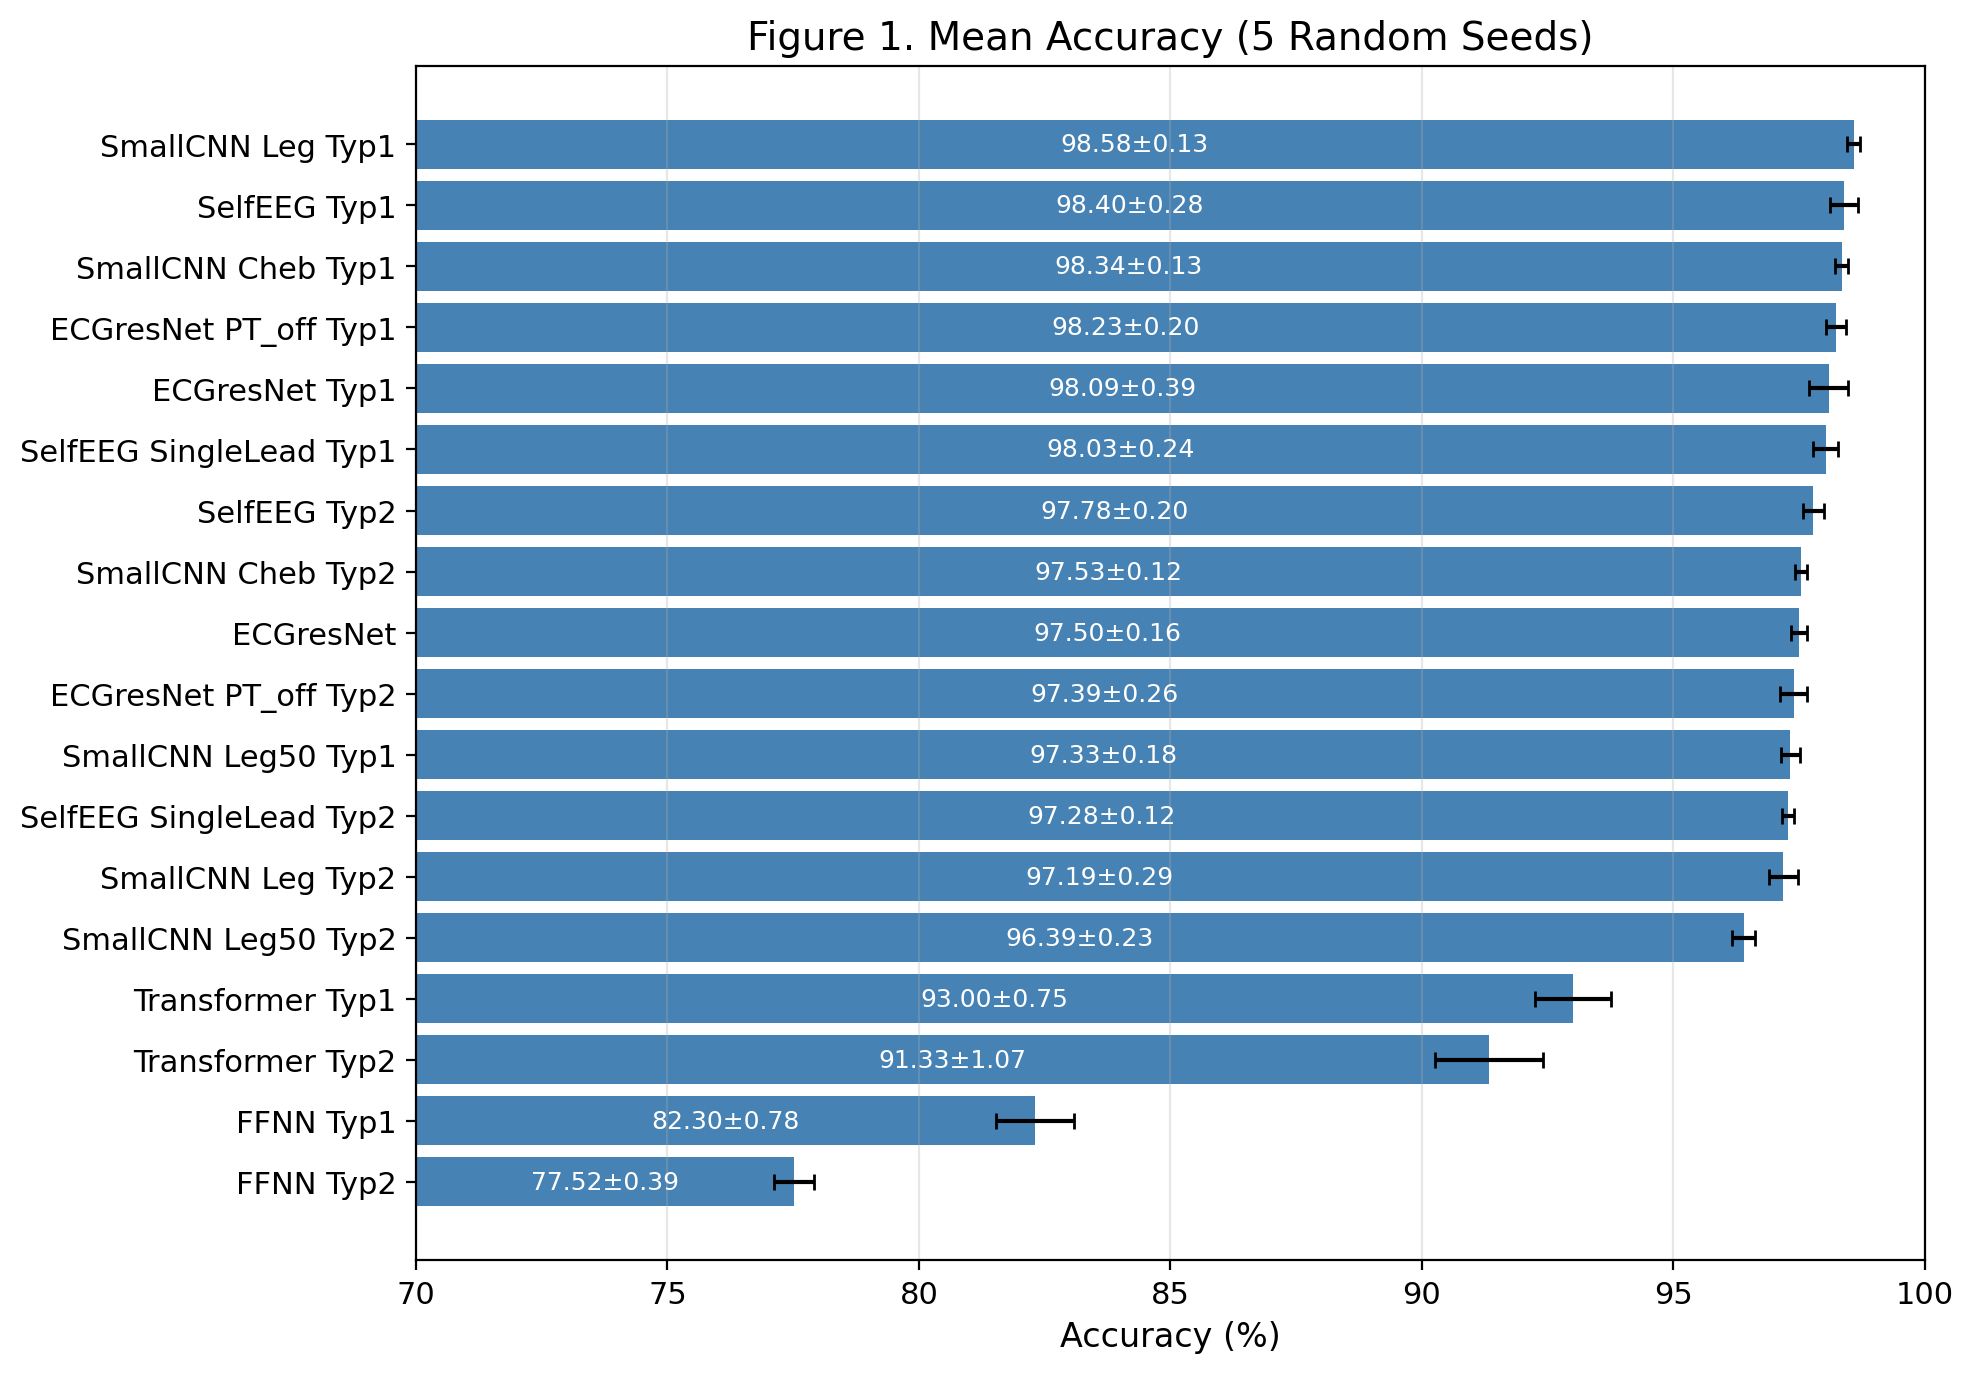

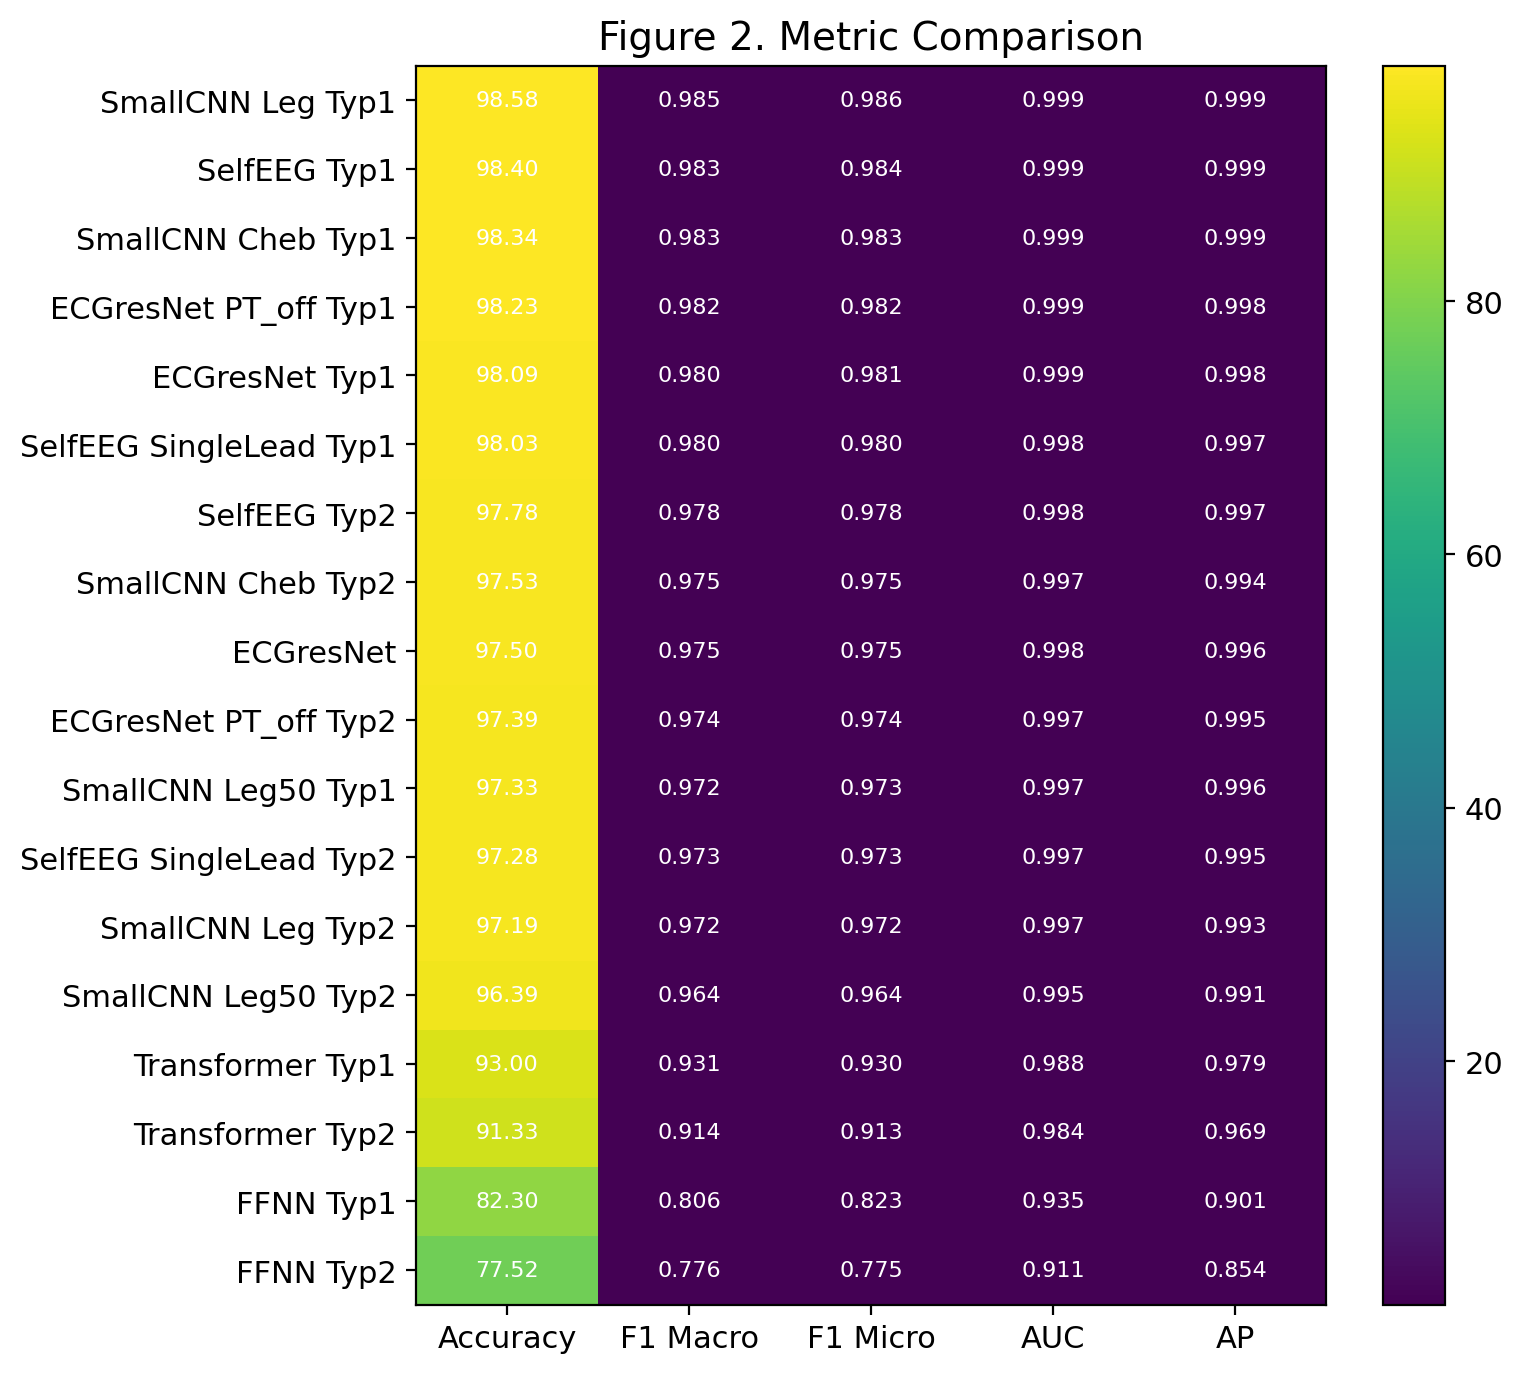

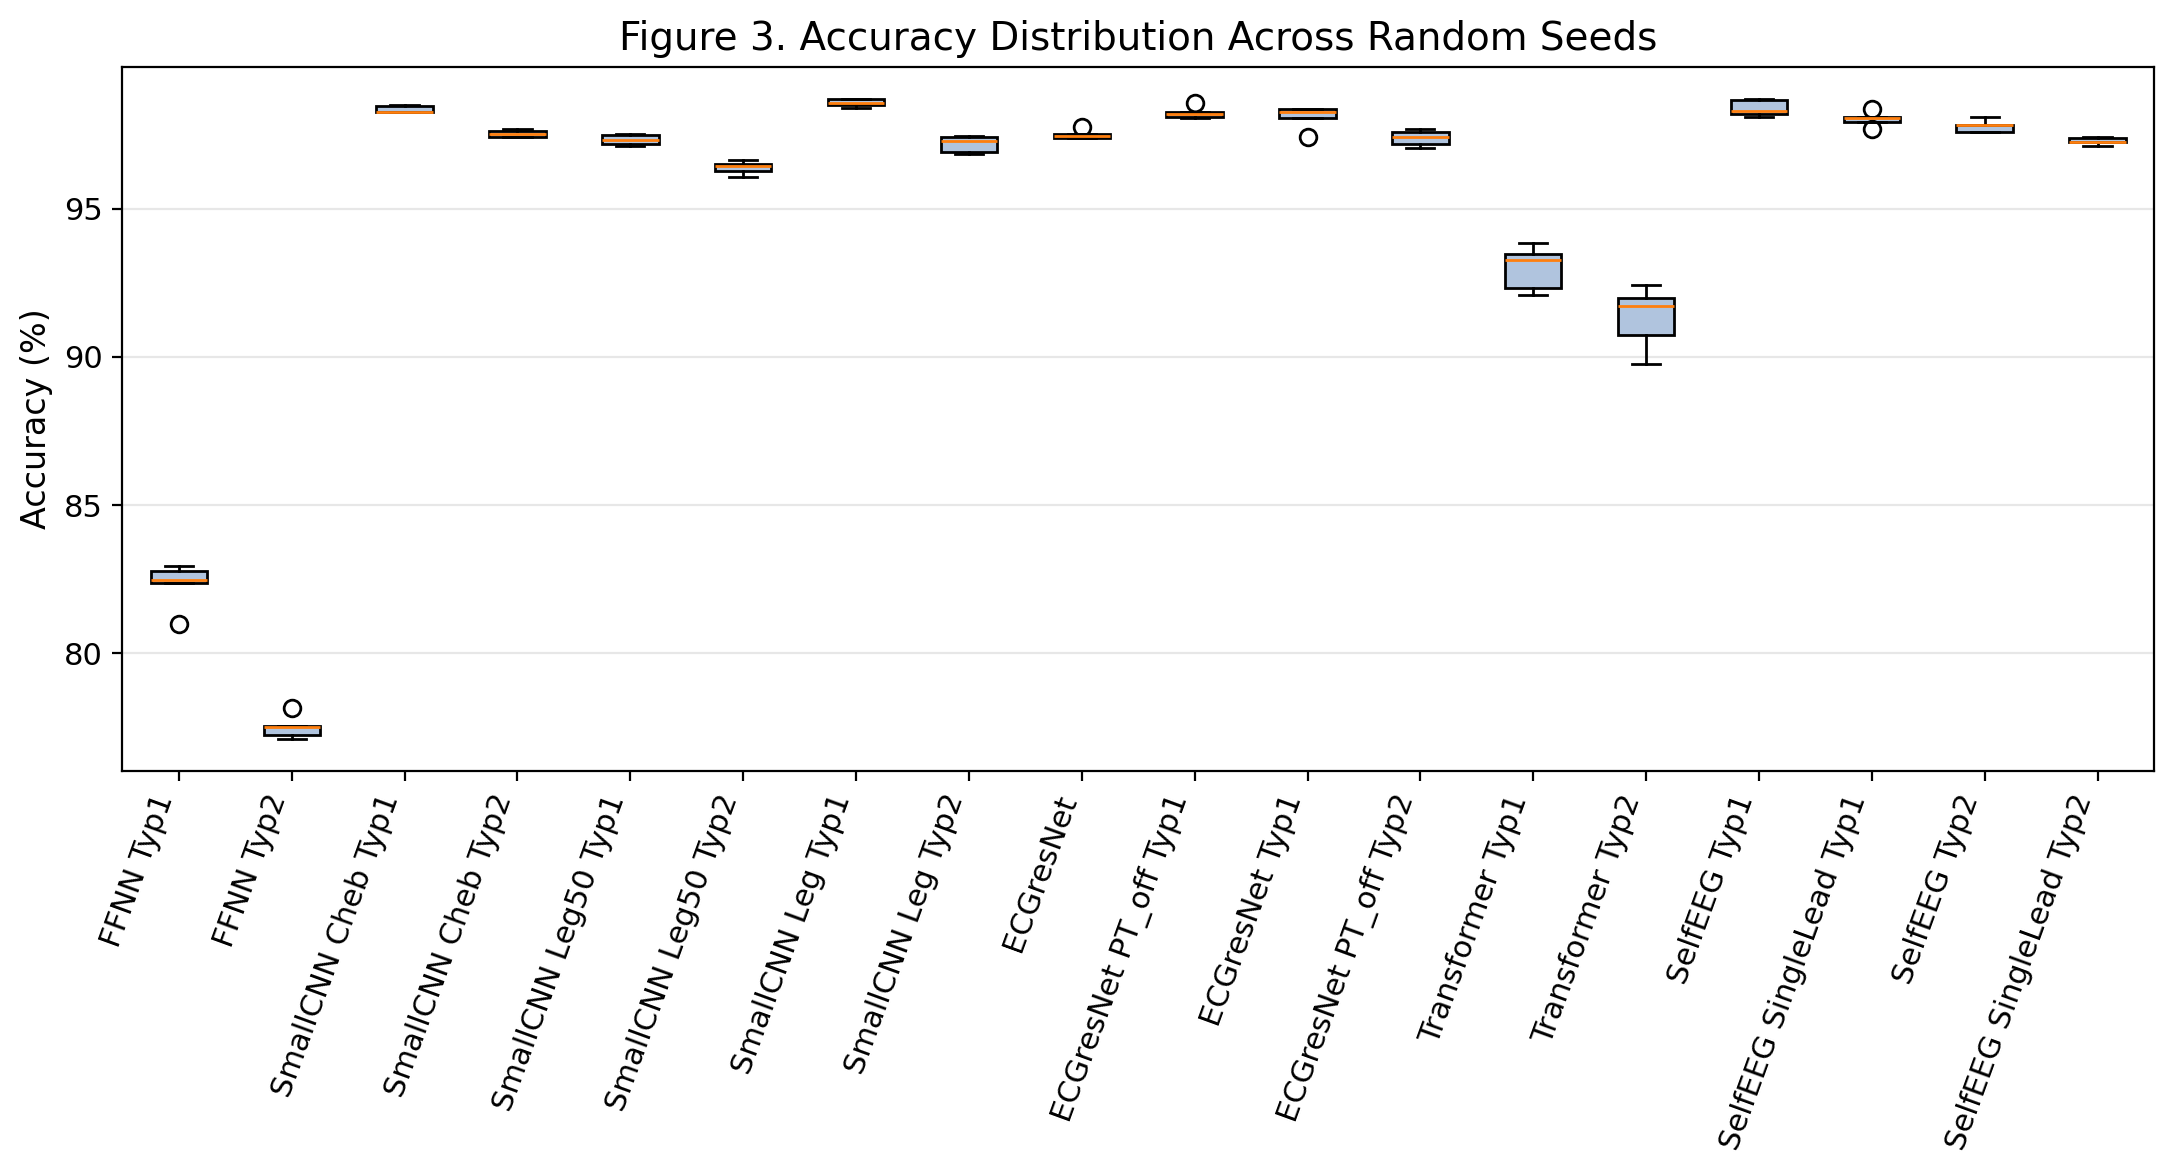

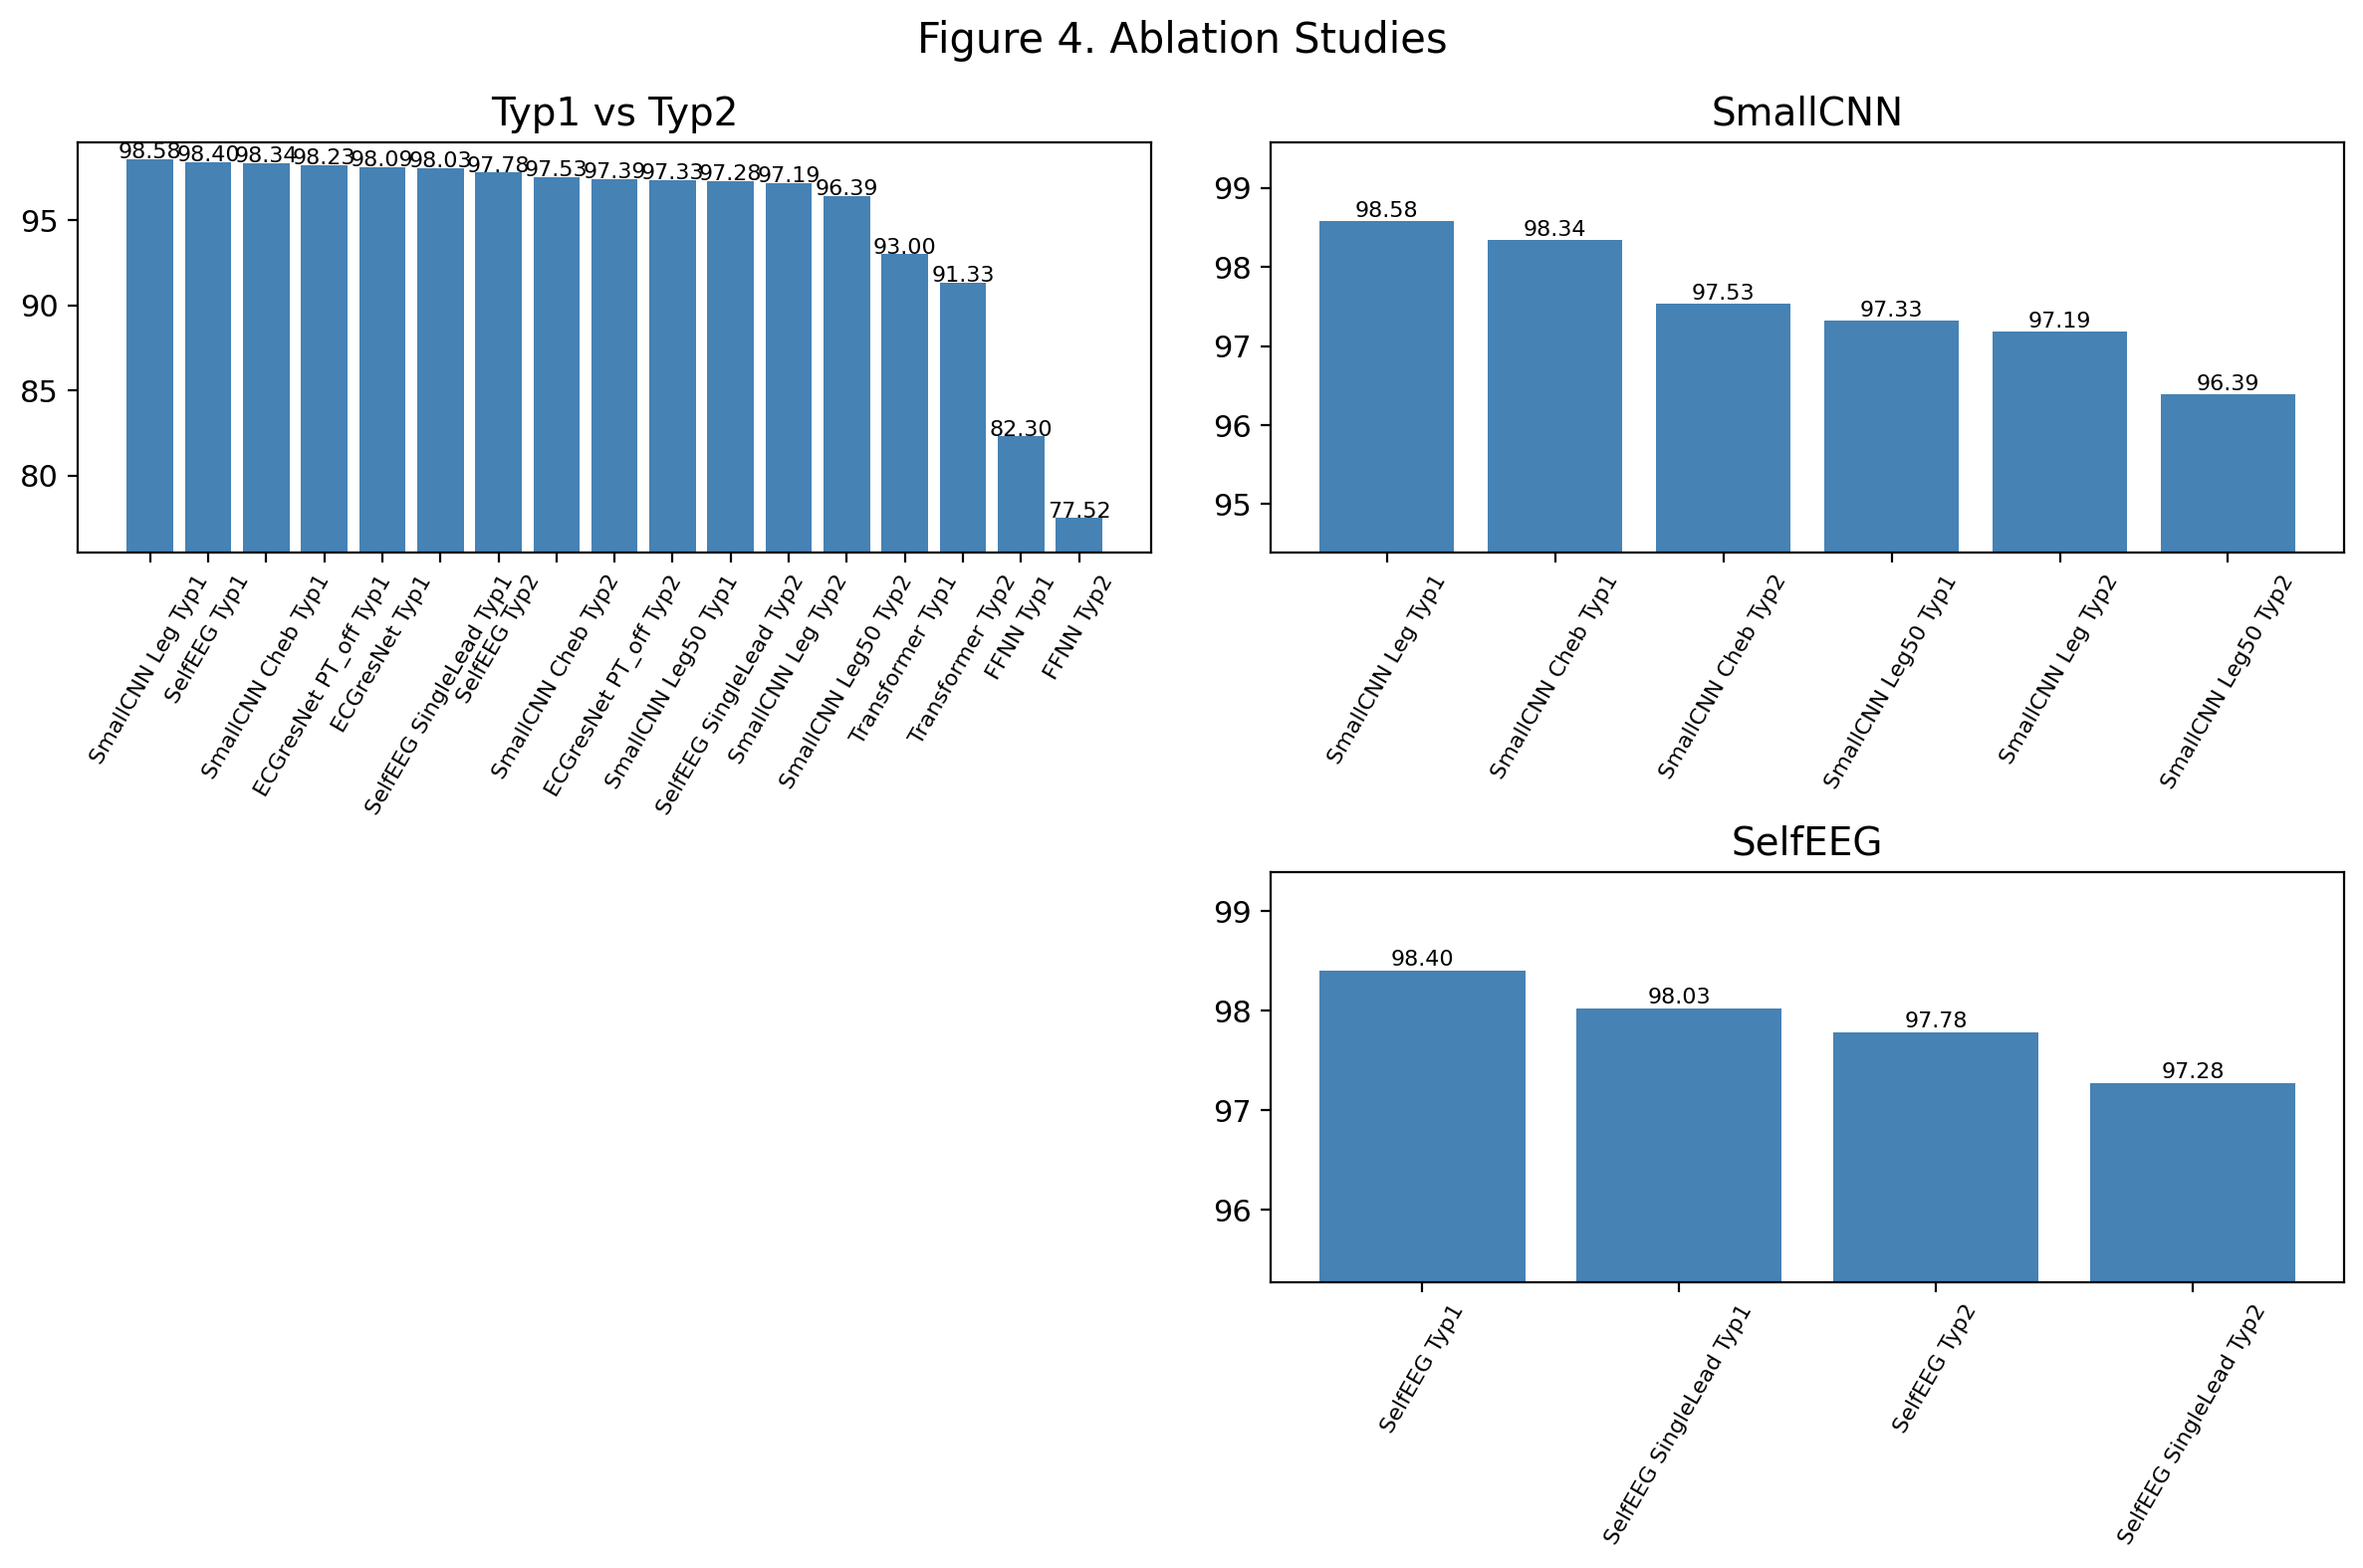

In [3]:

# Publication-quality experiment comparison
# Place this notebook/script inside MAIN/

from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size":11,
    "axes.titlesize":14,
    "axes.labelsize":12,
    "figure.dpi":200
})

MAIN=Path.cwd()

def short_name(name):
    s=name.replace("EXPERIMENT_","").replace("_randomseed","")
    model="SmallCNN" if "smallcnn" in s else "ECGresNet" if "ECGresnet" in s else "SelfEEG" if "selfeeg" in s else "Transformer" if "transformer" in s else "FFNN" if "ffnn" in s else "Model"
    enc=""
    if "leg_50" in s: enc="Leg50"
    elif "leg" in s: enc="Leg"
    elif "cheb" in s: enc="Cheb"
    typ="Typ1" if "typ1" in s else "Typ2" if "typ2" in s else ""
    extras=[]
    if "singlelead1" in s: extras.append("SingleLead")
    if "pretrain" in s: extras.append("PT_off")
    return " ".join([x for x in [model,enc,*extras,typ] if x])

rows=[]
seed_acc={}

for d in sorted(MAIN.glob("EXPERIMENT*_randomseed")):
    csv=list(d.glob("*.csv"))
    if not csv: continue
    df=pd.read_csv(csv[0])
    m=df[df.seed.astype(str)=="mean"].iloc[0]
    sd=df[df.seed.astype(str)=="std"].iloc[0]
    nm=short_name(d.name)
    rows.append({
        "Experiment":nm,
        "Accuracy":float(m.accuracy),
        "Std":float(sd.accuracy),
        "F1 Macro":float(m.f1_macro),
        "F1 Micro":float(m.f1_micro),
        "AUC":float(m.auc_macro),
        "AP":float(m.ap_micro)
    })
    seed=df[pd.to_numeric(df.seed,errors="coerce").notna()]
    seed_acc[nm]=seed.accuracy.astype(float).values

comp=pd.DataFrame(rows).sort_values("Accuracy",ascending=False).reset_index(drop=True)
display(comp)

# ---------- Figure 1 ----------
fig,ax=plt.subplots(figsize=(10,7))
y=np.arange(len(comp))
ax.barh(y,comp.Accuracy,xerr=comp.Std,color="steelblue",ecolor="black",capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(comp.Experiment)
ax.invert_yaxis()
ax.set_xlim(70, 100)
ax.set_xlabel("Accuracy (%)")
ax.set_title("Figure 1. Mean Accuracy (5 Random Seeds)")
for i,(a,s) in enumerate(zip(comp.Accuracy,comp.Std)):
    ax.text(70 + (a-70)/2, i, f"{a:.2f}±{s:.2f}", va="center", ha="center", fontsize=9, color="white")
ax.grid(axis="x",alpha=.3)
plt.tight_layout()
plt.show()

# ---------- Figure 2 ----------
metrics=["Accuracy","F1 Macro","F1 Micro","AUC","AP"]
fig,ax=plt.subplots(figsize=(8,7))
data=comp[metrics].values
im=ax.imshow(data,aspect="auto",cmap="viridis")
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics)
ax.set_yticks(range(len(comp)))
ax.set_yticklabels(comp.Experiment)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        txt=f"{data[i,j]:.2f}" if j==0 else f"{data[i,j]:.3f}"
        ax.text(j,i,txt,ha="center",va="center",color="white",fontsize=8)
ax.set_title("Figure 2. Metric Comparison")
plt.colorbar(im)
plt.tight_layout()
plt.show()

# ---------- Figure 3 ----------
fig,ax=plt.subplots(figsize=(11,6))
labels=list(seed_acc.keys())
vals=[seed_acc[k] for k in labels]
bp=ax.boxplot(vals,patch_artist=True,tick_labels=labels)
for b in bp["boxes"]:
    b.set_facecolor("lightsteelblue")
plt.xticks(rotation=70,ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Figure 3. Accuracy Distribution Across Random Seeds")
plt.grid(axis="y",alpha=.3)
plt.tight_layout()
plt.show()

# ---------- Figure 4 ----------
fig,axs=plt.subplots(2,2,figsize=(12,8))
axs=axs.ravel()

groups={
"Typ1 vs Typ2": comp[comp.Experiment.str.contains("Typ")],
"SmallCNN": comp[comp.Experiment.str.startswith("SmallCNN")],
"ECGResNet": comp[comp.Experiment.str.startswith("ECGResNet")],
"SelfEEG": comp[comp.Experiment.str.startswith("SelfEEG")]
}

for ax,(title,df) in zip(axs,groups.items()):
    if df.empty:
        ax.axis("off")
        continue
    bars=ax.bar(df.Experiment,df.Accuracy,color="steelblue")
    ax.set_title(title)
    ax.tick_params(axis="x",rotation=60,labelsize=8)
    ax.set_ylim(df.Accuracy.min()-2,df.Accuracy.max()+1)
    for b,v in zip(bars,df.Accuracy):
        ax.text(b.get_x()+b.get_width()/2,v+0.05,f"{v:.2f}",ha="center",fontsize=8)

plt.suptitle("Figure 4. Ablation Studies",fontsize=15)
plt.tight_layout()
plt.show()


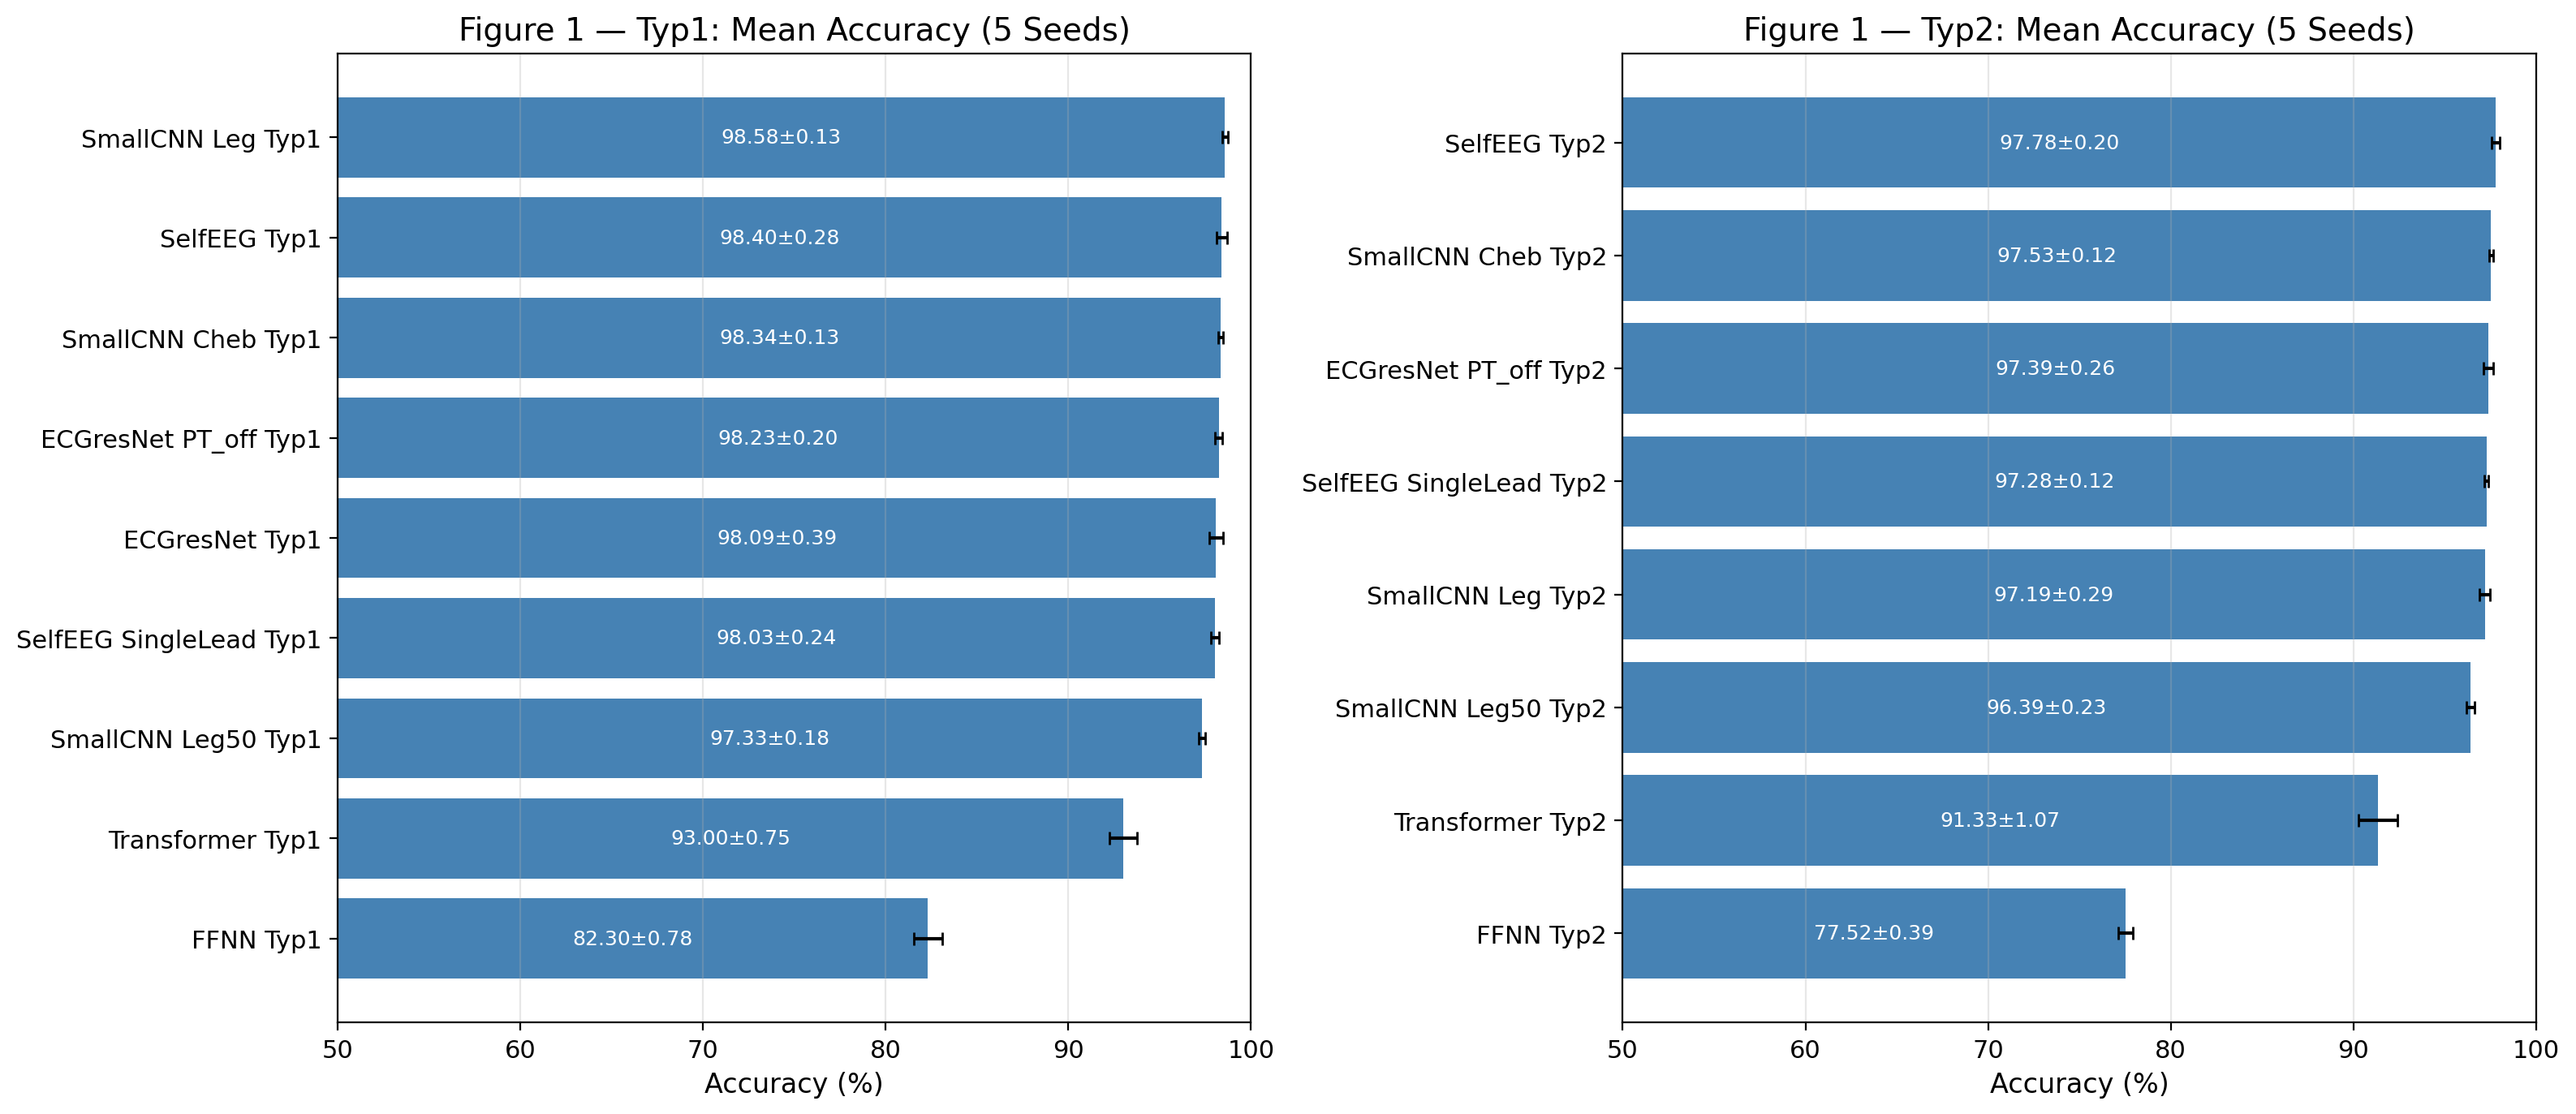

In [4]:
# ---------- Figure 1 ----------
typ1 = comp[comp.Experiment.str.contains("Typ1")].reset_index(drop=True)
typ2 = comp[comp.Experiment.str.contains("Typ2")].reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, title in [(ax1, typ1, "Typ1"), (ax2, typ2, "Typ2")]:
    y = np.arange(len(df))
    ax.barh(y, df.Accuracy, xerr=df.Std, color="steelblue", ecolor="black", capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(df.Experiment)
    ax.invert_yaxis()
    ax.set_xlim(50, 100)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title(f"Figure 1 — {title}: Mean Accuracy (5 Seeds)")
    for i, (a, s) in enumerate(zip(df.Accuracy, df.Std)):
        ax.text(50 + (a - 50) / 2, i, f"{a:.2f}±{s:.2f}",
                va="center", ha="center", fontsize=9, color="white")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
